In [1]:
import numpy as np
from dataclasses import dataclass
from typing import Optional
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
from astropy import units as u
from astropy import constants as const

C_KMS = const.c.to(u.km/u.s).value

@dataclass
class CosmoParams:
    H0: float = 70.0            # [km/s/Mpc]
    Om0: float = 0.3            # Ω_m
    Ok0: float = 0.0            # Ω_k
    Or0: float = 0.0            # Ω_r (可忽略时设 0)
    # 暗能量状态方程：二选一
    w: Optional[float] = None      # 常数 w
    w0: float = -1.0            # CPL: w(a)=w0+wa(1-a)
    wa: float = 0.0

    def Ode0(self) -> float:
        return 1.0 - self.Om0 - self.Ok0 - self.Or0

def _rho_de_factor(z: float, cp: CosmoParams) -> float:
    """ρ_DE(z)/ρ_DE(0) 的无量纲演化因子。"""
    if cp.w is not None:  # 常数 w
        return (1.0 + z)**(3.0 * (1.0 + cp.w))
    # CPL: w(a)=w0+wa(1-a) => ρ_DE ∝ (1+z)^{3(1+w0+wa)} exp[-3 wa z/(1+z)]
    return (1.0 + z)**(3.0 * (1.0 + cp.w0 + cp.wa)) * np.exp(-3.0 * cp.wa * z / (1.0 + z))

def Ez(z: float, cp: CosmoParams) -> float:
    """E(z) = H(z)/H0."""
    de = cp.Ode0() * _rho_de_factor(z, cp)
    return np.sqrt(cp.Om0 * (1.0 + z)**3 + cp.Or0 * (1.0 + z)**4 + cp.Ok0 * (1.0 + z)**2 + de)

def _chi_quad(z: float, cp: CosmoParams) -> float:
    """无量纲共动径向距离 χ(z) = ∫_0^z dz'/E(z')."""
    if _HAS_SCIPY:
        val, _ = quad(lambda zp: 1.0 / Ez(zp, cp), 0.0, float(z), epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    # 简单梯形积分后备方案
    zgrid = np.linspace(0.0, float(z), 4097)
    return np.trapz(1.0 / np.vectorize(Ez)(zgrid, cp), zgrid)

def _Sk(x: float, Ok0: float) -> float:
    """曲率函数 S_k(x)。注意这里的 x 是 √|Ω_k| χ。"""
    if abs(Ok0) < 1e-12:
        return x
    if Ok0 > 0.0:  # open, sinh
        return np.sinh(x)
    else:          # closed, sin
        return np.sin(x)

def D_M(z: float, cp: CosmoParams) -> float:
    """横向共动距离 D_M(z) [Mpc]."""
    chi = _chi_quad(z, cp)
    if abs(cp.Ok0) < 1e-12:
        return (C_KMS / cp.H0) * chi
    sqrtOk = np.sqrt(abs(cp.Ok0))
    return (C_KMS / cp.H0) * _Sk(sqrtOk * chi, cp.Ok0) / sqrtOk

def D_A(z: float, cp: CosmoParams) -> float:
    """角径距 D_A(0→z) [Mpc]."""
    return D_M(z, cp) / (1.0 + z)

def D_A12(z1: float, z2: float, cp: CosmoParams) -> float:
    """两红移间角径距 D_A(z1→z2) [Mpc], 需 z2>z1。"""
    if not (z2 > z1):
        raise ValueError("Require z2 > z1 for D_A12.")
    chi1 = _chi_quad(z1, cp)
    chi2 = _chi_quad(z2, cp)
    dchi = chi2 - chi1
    if abs(cp.Ok0) < 1e-12:
        DM12 = (C_KMS / cp.H0) * dchi
    else:
        sqrtOk = np.sqrt(abs(cp.Ok0))
        DM12 = (C_KMS / cp.H0) * _Sk(sqrtOk * dchi, cp.Ok0) / sqrtOk
    return DM12 / (1.0 + z2)

# ---- 封装常用距离 ----
def Dl(zl: float, cp: CosmoParams) -> float: return D_A(zl, cp)
def Ds(zs: float, cp: CosmoParams) -> float: return D_A(zs, cp)
def Dls(zl: float, zs: float, cp: CosmoParams) -> float: return D_A12(zl, zs, cp)

# =========================
# 1) 星系–星系透镜：R = Ds / Dls
# =========================
def galaxy_lens_distance_ratio(zl: float, zs: float, *,
                               H0: float, omega_m: float,
                               omega_k: float = 0.0, omega_r: float = 0.0,
                               w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回 R = D_s / D_ls （无量纲），仅含宇宙学部分。
    注：真实建模还需乘以结构因子 F(γ, β_ani, θ_ap/θ_E) 才能与(θ_E, σ_ap)组合。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 2) 时延 AGN：D_dt = (1+zl) Dl Ds / Dls
# =========================
def time_delay_distance(zl: float, zs: float, *,
                        H0: float, omega_m: float,
                        omega_k: float = 0.0, omega_r: float = 0.0,
                        w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回时延距离 D_Δt [Mpc]： (1+zl) * Dl * Ds / Dls
    注意：观测上 D_Δt 还会被外会聚 κ_ext 等效缩放，建模需单独处理。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 3) 双源透镜：β_DSP = (D_ls2/D_s2) / (D_ls1/D_s1)
# =========================
def double_source_beta(zl: float, zs1: float, zs2: float, *,
                       H0: float, omega_m: float,
                       omega_k: float = 0.0, omega_r: float = 0.0,
                       w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回双源透镜的宇宙学量 β_DSP （无量纲）。
    要求 zl < zs1 < zs2。
    """
    if not (zl < zs1 < zs2):
        raise ValueError("Require zl < zs1 < zs2 for double-source lensing.")
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    num = Dls(zl, zs2, cp) / Ds(zs2, cp)
    den = Dls(zl, zs1, cp) / Ds(zs1, cp)
    return num / den

import numpy as np

def _as_float(x):
    # 确保传给积分器的是标量 float
    return float(np.asarray(x))

def galaxy_lens_distance_ratio_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 R = Ds/Dls（与 zl、zs 广播后的形状一致）。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            # o[...] = Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
            o[...] = Dls(zl_f, zs_f, cp) / Ds(zs_f, cp)
    return out

def time_delay_distance_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 D_dt [Mpc] = (1+zl) * Dl * Ds / Dls。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            o[...] = (1.0 + zl_f) * Dl(zl_f, cp) * Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def double_source_beta_vec(
    zl, zs1, zs2, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 β_DSP = (D_ls2/D_s2)/(D_ls1/D_s1)。
    仅当 zl < zs1 < zs2 时有效，否则该元素 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, z1A, z2A = np.broadcast_arrays(np.asarray(zl, float),
                                        np.asarray(zs1, float),
                                        np.asarray(zs2, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, z1A, z2A, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['readonly'], ['writeonly']])
    for zl_i, z1_i, z2_i, o in it:
        zl_f, z1_f, z2_f = _as_float(zl_i), _as_float(z1_i), _as_float(z2_i)
        if not (zl_f < z1_f < z2_f):
            o[...] = np.nan
        else:
            num = Dls(zl_f, z2_f, cp) / Ds(z2_f, cp)
            den = Dls(zl_f, z1_f, cp) / Ds(z1_f, cp)
            o[...] = num / den
    return out



In [12]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

# ====== 1) 时延距离标量 ======
def Ddt_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return time_delay_distance(float(zl), float(zs), **cosmo)

def dlnR_dp(zl: float, zs: float, cosmo: dict, p: str,
            eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    base = R_scalar(zl, zs, cosmo)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo.get(p, None)
    # step choice
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus = (val - dp) if (val is not None) else -dp
        p_plus  = (val + dp) if (val is not None) else  dp
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # physical guards
    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5); p_plus = np.clip(p_plus, -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    c_m = cosmo.copy(); c_m[p] = p_minus
    c_p = cosmo.copy(); c_p[p] = p_plus
    Rm = R_scalar(zl, zs, c_m)
    Rp = R_scalar(zl, zs, c_p)
    if (Rm <= 0) or (Rp <= 0) or (not np.isfinite(Rm)) or (not np.isfinite(Rp)):
        return np.nan
    return float((np.log(Rp) - np.log(Rm)) / (p_plus - p_minus))

# ====== 2) 数值导数：∂ ln D_dt / ∂ p ======
def dlnDdt_dp(zl: float, zs: float, cosmo: Dict, p: str,
              eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    cosmo_p = cosmo.copy()
    base = Ddt_scalar(zl, zs, cosmo_p)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo_p.get(p, None)
    # 步长
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus, p_plus = (val - dp if val is not None else -dp), (val + dp if val is not None else dp)
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # 物理边界
    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5)
        p_plus  = np.clip(p_plus,  -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    # 中心差分
    cosmo_m = cosmo.copy();  cosmo_m[p]  = p_minus
    cosmo_p2 = cosmo.copy(); cosmo_p2[p] = p_plus
    Dm = Ddt_scalar(zl, zs, cosmo_m)
    Dp = Ddt_scalar(zl, zs, cosmo_p2)
    if (Dm <= 0) or (Dp <= 0) or (not np.isfinite(Dm)) or (not np.isfinite(Dp)):
        return np.nan

    return float((np.log(Dp) - np.log(Dm)) / (p_plus - p_minus))

# ====== helper：确保 H0 在参数列表里，并返回去重后的顺序表 ======
def _with_H0(params: List[str]) -> List[str]:
    seen = set()
    out = []
    for p in list(params) + ["H0"]:
        if p not in seen:
            out.append(p); seen.add(p)
    return out

# ====== 3) Fisher：单点 & 累积（始终把 H0 纳入）======
def fisher_single(zl: float, zs: float, cosmo: Dict, params: List[str], sigma_frac: float):
    """
    返回 (F, params_eff)：
      - F: (len(params_eff) x len(params_eff)) Fisher 矩阵
      - params_eff: 实际使用的参数顺序（原 params + 'H0'，去重）
    """
    params_eff = _with_H0(params)
    J = np.array([dlnDdt_dp(zl, zs, cosmo, p) for p in params_eff], dtype=float)  # ∂ln D_dt/∂p
    if not np.all(np.isfinite(J)):
        return np.zeros((len(params_eff), len(params_eff))), params_eff
    F = np.outer(J, J) / (sigma_frac**2)
    return F, params_eff

def fisher_cumulative(zl_arr: np.ndarray, zs: float, cosmo: Dict, params: List[str], sigma_frac: float):
    """
    把一个 z_s 下所有 z_l 的 Fisher 相加。
    返回 (F, params_eff)。
    """
    params_eff = _with_H0(params)
    F = np.zeros((len(params_eff), len(params_eff)), dtype=float)
    for zl in zl_arr:
        if zl <= 0 or zl >= zs:
            continue
        F_k, _ = fisher_single(float(zl), float(zs), cosmo, params_eff, sigma_frac)
        F += F_k
    return F, params_eff

# ====== 4) zl 网格 ======
def zl_grid_for_zs(zs: float, dz: float = 0.004) -> np.ndarray:
    n = max(1, int(np.floor(zs / dz)))
    eps = 1e-6 * max(1.0, zs)
    return np.linspace(eps, zs - eps, n)

# ====== 5) 局部敏感度：支持直接画 H0 ======
def plot_local_sensitivity(zs_list, param, cosmo, sigma_frac=0.05, dz=0.004):
    """
    sensitivity ≡ |∂ln D_dt/∂p| / σ_lnD；σ_lnD≈sigma_frac。
    """
    plt.figure(figsize=(8,5))
    for zs in zs_list:
        zls = zl_grid_for_zs(zs, dz=dz)
        sens = []
        for zl in zls:
            d = dlnDdt_dp(zl, zs, cosmo, param)
            sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
        plt.plot(zls, sens, label=f"z_s={zs:.1f}")

    plt.yscale('log')
    plt.xlabel(r"$z_l$")
    plt.ylabel(rf"Sensitivity: $|\partial \ln D_{{\Delta t}}/\partial {param}|\,/\,\sigma_{{\ln D}}$")
    plt.title(rf"Time-delay: Local sensitivity for {param}  (σ$_{{D_\Delta t}}$/D$_{{\Delta t}}$ = {sigma_frac:.1%})")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)

    if param == "omega_m":
        ymin, ymax = plt.ylim()
        plt.ylim(bottom=0.5, top=max(ymax, 0.5))

    plt.tight_layout()
    plt.show()

# ====== 6) 累积边际化敏感度：自动把 H0 纳入边际化 ======
def plot_cumulative_marginalized(zs_list, params, cosmo, sigma_frac=0.05, dz=0.004, param_to_plot=None):
    """
    对每个 z_s，把 [0,z_s) 的 z_l Fisher 累加，C=F^{-1}，画 1/sqrt(C_ii)。
    始终把 H0 纳入 params 并边际化。
    """
    zs_list = list(zs_list)

    if param_to_plot is not None:
        ys = []
        for zs in zs_list:
            F, params_eff = fisher_cumulative(zl_grid_for_zs(zs, dz=dz), zs, cosmo, params, sigma_frac)
            if np.linalg.matrix_rank(F) < len(params_eff) or (param_to_plot not in params_eff):
                ys.append(np.nan)
            else:
                C = np.linalg.inv(F)
                idx = params_eff.index(param_to_plot)
                sigma_i = np.sqrt(C[idx, idx])
                ys.append(1.0 / sigma_i if sigma_i > 0 else np.nan)
        plt.figure(figsize=(6,4))
        plt.plot(zs_list, ys, marker='o')
        plt.yscale('log')
        plt.xlabel(r"$z_s$")
        plt.ylabel(rf"Sensitivity: $1/\sigma({param_to_plot})$ (marginalized)")
        plt.title(rf"Time-delay: Cumulative marginalized sensitivity (σ$_{{D_\Delta t}}$/D$_{{\Delta t}}$ = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(7,5))
        # 这里的 params_eff 在不同 zs 可变，但一般稳定；用第一个 zs 确定图例顺序
        F0, params_eff0 = fisher_cumulative(zl_grid_for_zs(zs_list[0], dz=dz), zs_list[0], cosmo, params, sigma_frac)
        for j, p in enumerate(params_eff0):
            ys = []
            for zs in zs_list:
                F, params_eff = fisher_cumulative(zl_grid_for_zs(zs, dz=dz), zs, cosmo, params, sigma_frac)
                if (np.linalg.matrix_rank(F) < len(params_eff)) or (p not in params_eff):
                    ys.append(np.nan)
                else:
                    C = np.linalg.inv(F)
                    jj = params_eff.index(p)
                    sigma_j = np.sqrt(C[jj, jj])
                    ys.append(1.0 / sigma_j if sigma_j > 0 else np.nan)
            plt.plot(zs_list, ys, marker='o', label=p)

        plt.yscale('log')
        plt.xlabel(r"$z_s$")
        plt.ylabel("Sensitivity: $1/\\sigma(\\cdot)$  (marginalized)")
        plt.title(rf"Time-delay: Cumulative marginalized sensitivity vs $z_s$ (σ$_{{D_\Delta t}}$/D$_{{\Delta t}}$ = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


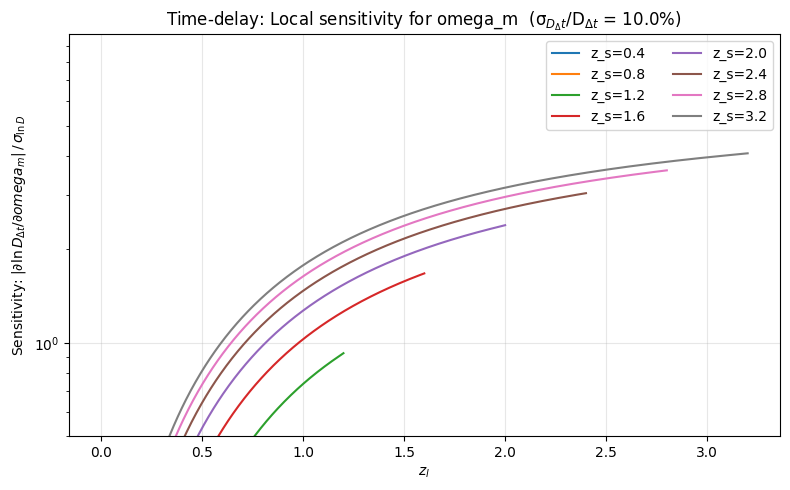

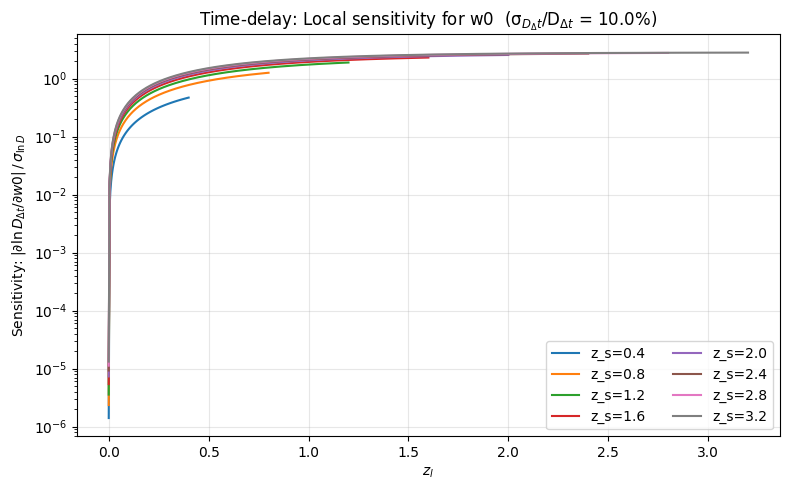

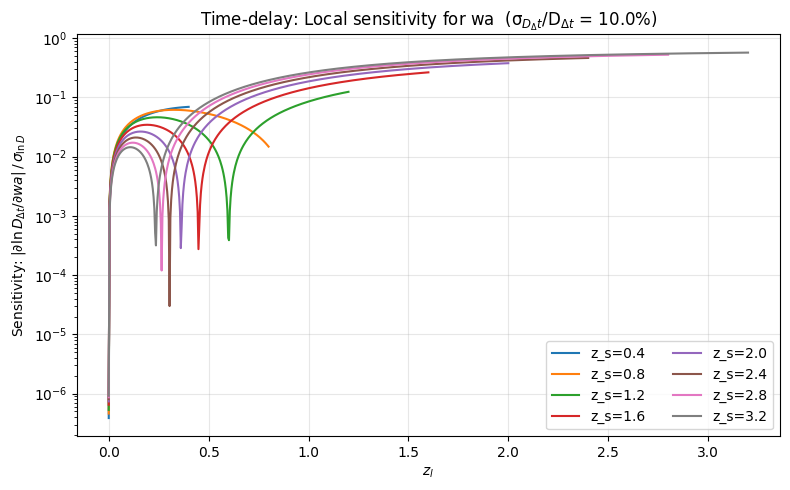

In [3]:
# ====== 7) 示例调用 ======
if __name__ == "__main__":
    # 选择模型：常数 w（传 w），或 CPL（不传 w，传 w0, wa）
    # 例：wCDM
    cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
    # 例：CPL
    cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

    zs_list = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]
    sigma_frac = 0.1   # 假设单个 R 的相对误差 5%，可改为 0.02 等
    dz = 0.004          # 你的网格步长

    # # —— 画“局部约束能力”曲线（每个参数各 8 条曲线）——
    # # 对 Ωm：
    plot_local_sensitivity(zs_list, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # # 对 常数 w（若你用 wCDM）：
    # plot_local_sensitivity(zs_list, param="w",       cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # # 或者对 CPL: w0, wa（若你用 CPL）
    plot_local_sensitivity(zs_list, param="w0",      cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)
    plot_local_sensitivity(zs_list, param="wa",      cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)

    # # —— 可选：画“累积边际化”约束（把一个 zs 下所有 zl 相加）——
    # # 多参数同时边际化（示例：Ωm 与 w）：
    # params_wcdm = ["omega_m", "w"]
    # plot_cumulative_marginalized(zs_list, params=params_wcdm, cosmo=cosmo_wcdm,
    #                              sigma_frac=sigma_frac, dz=dz, param_to_plot=None)
    # 或只画某一个参数的累积边际化误差：
    # plot_cumulative_marginalized(zs_list, params=params_wcdm, cosmo=cosmo_wcdm,
    #                              sigma_frac=sigma_frac, dz=dz, param_to_plot="omega_m")

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# --------- generic 2x2 plotter (for R or D_dt) ----------
def _plot_sensitivity_vs_zl_quad(zs_list, cosmo, sigma_frac, dz, deriv_fn,
                                 title_prefix, ylabel_math, outputname):
    """
    Make a 2x2 figure for params ['omega_m','omega_k','w0','wa'].
    Each subplot shows sensitivity(z_l) for multiple z_s in zs_list.
      deriv_fn(zl, zs, cosmo, p) -> ∂ ln O / ∂ p
      ylabel_math: LaTeX for observable, e.g. r"D_s/D_{ls}" or r"D_{{\\Delta t}}"
    """
    params = ["omega_m", "omega_k", "w0", "wa"]
    titles = [r"$\Omega_m$", r"$\Omega_k$", r"$w_0$", r"$w_a$"]

    # Reserve space on the right for a vertical legend column
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=False, sharey=False)
    axes = axes.ravel()

    for ax, p, ttl in zip(axes, params, titles):
        for zs in zs_list:
            zls = zl_grid_for_zs(zs, dz=dz)   # (0, zs)
            sens = []
            for zl in zls:
                d = deriv_fn(zl, zs, cosmo, p)
                sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
            y = np.asarray(sens, float)
            m = np.isfinite(zls) & np.isfinite(y)
            if np.any(m):
                ax.plot(zls[m], y[m], lw=1.6, label=fr"$z_s={zs:.1f}$")

        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        ax.set_title(ttl)
        ax.set_xlabel(r"$z_l$",fontsize=15,)
        ax.set_ylabel(fr"Sensitivity: $|\partial \ln {ylabel_math}/\partial p|/\sigma_{{\ln {ylabel_math}}}$")

        # Optional y-limits
        ymin, ymax = ax.get_ylim()
        if p == "omega_m":
            ax.set_ylim(bottom=0.0001)
        elif p == "omega_k":
            ax.set_ylim(bottom=0.5)
        elif p == "w0":
            ax.set_ylim(bottom=0.1)
        elif p == "wa":
            ax.set_ylim(bottom=1e-5)

    # Build a single legend and place it outside on the right
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break
    if handles:
        # leave room on the right and put legend there
        fig.subplots_adjust(right=0.80)  # shrink axes area to 80% width
        fig.legend(handles, labels,
                   loc="center left", bbox_to_anchor=(0.82, 0.5), fontsize=15,
                   ncol=1, frameon=False, borderaxespad=0.0)

    # Title + tighter layout (respecting the reserved right margin)
    fig.suptitle(
        fr"{title_prefix}: sensitivity vs $z_l$  ($\sigma_{{{ylabel_math}}}/{{{ylabel_math}}}$ = {sigma_frac:.1%})",
        y=0.98, fontsize=13
    )
    plt.tight_layout(rect=[0.03, 0.03, 0.80, 0.94])  # [left, bottom, right, top]
    plt.savefig(outputname, dpi=300)
    plt.show()


# --------- 1) Distance ratio R = Ds / Dls  (H0 cancels) ----------
def plot_sensitivity_R_quad(zs_list, cosmo_cpl, sigma_frac=0.05, dz=0.004):
    """
    4 subplots (Ωm, Ωk, w0, wa): sensitivity of R=Ds/Dls vs z_l, for each z_s in zs_list.
    Use CPL {w0, wa}. If you pass a wCDM dict, make sure NOT to include 'w' here; use w0=-1, wa=0.
    """
    # enforce CPL keys
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)  # ensure CPL branch

    def deriv_fn(zl, zs, c, p):
        return dlnR_dp(zl, zs, c, p)

    _plot_sensitivity_vs_zl_quad(
        zs_list, cosmo, sigma_frac, dz, deriv_fn,
        title_prefix=r"Distance ratio $R=D_s/D_{ls}$",
        ylabel_math=r"D_s/D_{ls}",
        outputname = r"fisher_dis_ratio01.png"
    )

# --------- 2) Time-delay distance D_dt = (1+zl) Dl Ds / Dls ----------
def plot_sensitivity_Ddt_quad(zs_list, cosmo_cpl, sigma_frac=0.05, dz=0.004):
    """
    4 subplots (Ωm, Ωk, w0, wa): sensitivity of D_dt vs z_l, for each z_s in zs_list.
    Uses CPL {w0, wa}. (You may still pass a wCDM dict; we convert to CPL with w0,wa.)
    """
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    def deriv_fn(zl, zs, c, p):
        return dlnDdt_dp(zl, zs, c, p)

    # Note: in f-strings, write D_{{\Delta t}} to escape braces correctly
    _plot_sensitivity_vs_zl_quad(
        zs_list, cosmo, sigma_frac, dz, deriv_fn,
        title_prefix=r"Time-delay distance $D_{\Delta t}$",
        ylabel_math=r"D_{{\Delta t}}",
        outputname = r"fisher_time-delay01.png"
    )


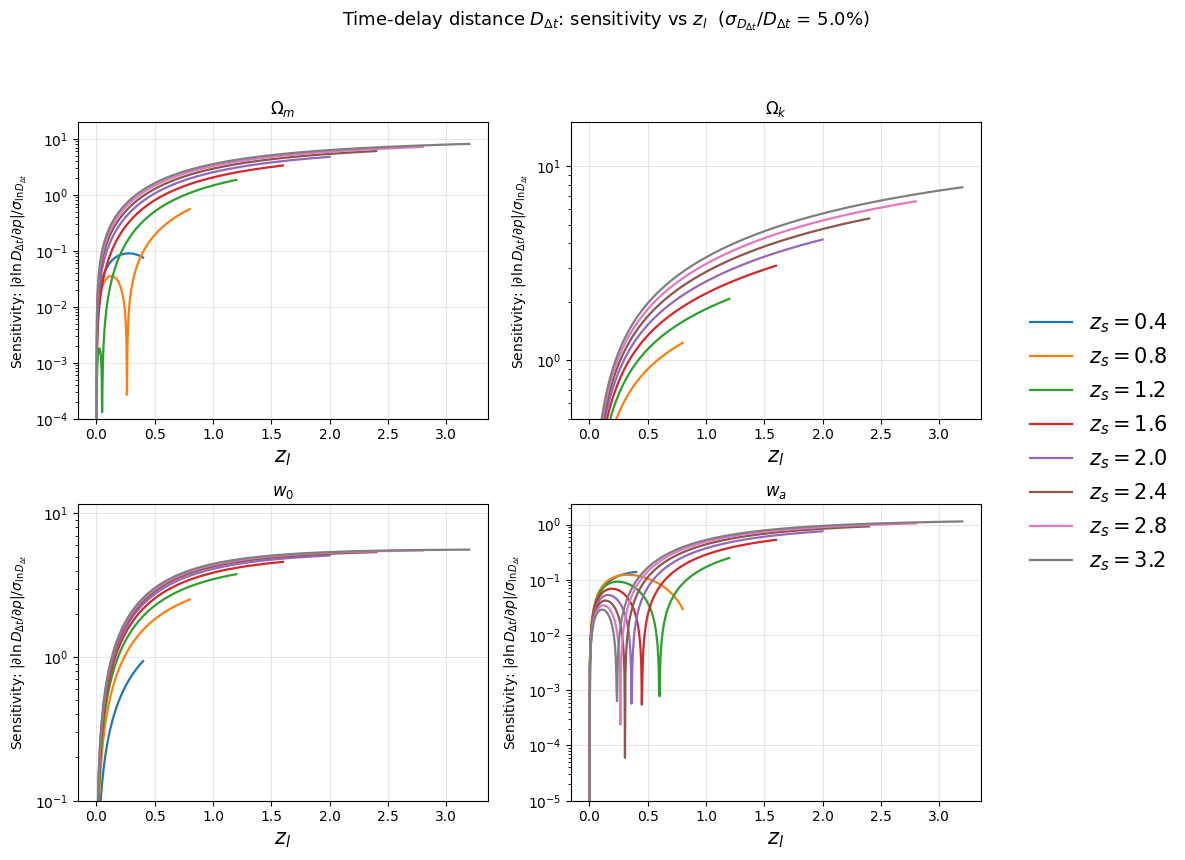

In [36]:
zs_list   = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8,3.2]
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
sigma_frac = 0.05
dz = 0.004

# plot_sensitivity_R_quad(zs_list, cosmo_cpl, sigma_frac=sigma_frac, dz=dz)
plot_sensitivity_Ddt_quad(zs_list, cosmo_cpl, sigma_frac=sigma_frac, dz=dz)
